# Buổi 8 — Tương quan giữa các chuỗi

**Một câu:** một hệ số tương quan giữa hai chuỗi thời gian dễ nói sai theo năm cách — xu hướng chung, quan hệ cong, độ trễ bị làm nhoè,
quan hệ đổi theo mùa, và biến thứ ba điều khiển cả hai; mỗi cách có một phép kiểm.

Tình huống: tải điện Texas (ERCOT) và nhiệt độ Dallas – Houston năm 2024, cùng CPI và dân số Mỹ 1990–2024. Nhiệt độ có dùng được để dự
báo tải không, và ở độ trễ nào? Sáu phần dưới đi qua năm cái bẫy.

| Phần | Câu hỏi |
|---|---|
| 1 | Một con số $r$ giấu được những gì? |
| 2 | Vì sao giá cả và dân số "tương quan 0,97"? |
| 3 | Nhiệt độ và tải: vì sao Pearson chỉ 0,62? |
| 4 | Nóng lên thì bao lâu sau tải mới tăng? |
| 5 | Quan hệ có giữ nguyên quanh năm không? |
| 6 | "Granger-gây-ra" nghĩa là gì, và không nghĩa là gì? |

## 0. Dữ liệu

**Bộ dữ liệu EIA-930 Hourly Electric Grid Monitor — BALANCE.** Cơ quan Thông tin Năng lượng Mỹ (EIA) thu từ mọi **vùng điều độ điện** (balancing authority — đơn vị giữ cân bằng cung
cầu điện trong một vùng, ví dụ PJM ở miền Đông, ERCOT ở Texas) **nhu cầu điện mỗi giờ**, dự báo ngày hôm trước của chính họ,
và sản lượng theo nguồn. Mỗi tệp là sáu tháng, mỗi dòng là **một giờ của một vùng**. Mốc giờ là **cuối giờ**: dòng 01:00 là
lượng điện của giờ 00:00–01:00.

Nguồn: Source: U.S. Energy Information Administration, Form EIA-930 Hourly Electric Grid Monitor (truy cập 2026-09-17); và 1 tệp cùng họ. Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `Balancing Authority` | mã vùng điều độ, ví dụ `PJM`, `ERCO` (ERCOT) |
| `UTC Time at End of Hour` | mốc giờ UTC, là **cuối** giờ đo |
| `Demand (MW)` | nhu cầu điện trung bình trong giờ (MW) — thứ cần dự báo |
| `Demand Forecast (MW)` | dự báo ngày hôm trước của chính vùng điều độ |

**Bộ dữ liệu Open-Meteo Historical Weather (ERA5).** Nhiệt độ **theo giờ** năm 2024 tại một điểm lưới ở thành phố, lấy từ Open-Meteo (dữ liệu tái phân tích ERA5 của châu
Âu). Tệp CSV có 3 dòng đầu là thông tin điểm lưới (toạ độ, độ cao, múi giờ), rồi mới tới bảng. Giờ ghi theo **UTC**, là nhiệt
độ tức thời đúng tại mốc giờ.

Nguồn: Weather data by Open-Meteo.com (https://open-meteo.com/), mô hình ERA5; và 1 tệp cùng họ. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `time` | giờ đo, **UTC** |
| `temperature_2m (°C)` | nhiệt độ ở độ cao 2 m |

**Bộ dữ liệu Consumer Price Index for All Urban Consumers (CPI-U).** Cục Thống kê Lao động Mỹ (BLS) theo dõi giá một giỏ hàng tiêu dùng mỗi tháng, từ 1913, quy về **1982–1984 = 100**.
Tệp là bảng dài phân cách bằng tab: mỗi dòng là một tháng của một chuỗi CPI. Chuỗi `CUUR0000SA0` là CPI mọi mặt hàng,
**chưa** điều chỉnh mùa vụ. Tháng 10/2025 BLS không công bố (ghi `-`).

Nguồn: U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers (truy cập 2026-09-17). Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `series_id` | mã chuỗi (có khoảng trắng thừa ở cuối); `CUUR0000SA0` = CPI mọi mặt hàng, chưa điều chỉnh mùa vụ |
| `year`, `period` | năm và tháng `M01`…`M12`; `M13` là trung bình năm — bỏ đi |
| `value` | giá trị chỉ số (1982–1984 = 100) |

**Bộ dữ liệu BEA National Income and Product Accounts — monthly.** Cục Phân tích Kinh tế Mỹ (BEA) công bố hệ thống tài khoản quốc gia; tệp này gom **mọi chuỗi theo tháng** vào một
bảng dài ba cột (khoảng 37 MB). Mỗi dòng là một tháng của một chuỗi. Chuỗi `B230RC` là **dân số giữa kỳ** của Mỹ, nghìn
người; `B230RC` tăng đều, không có mùa vụ.

Nguồn: Source: U.S. Bureau of Economic Analysis, National Income and Product Accounts (truy cập 2026-09-17). Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `%SeriesCode` | mã chuỗi, ví dụ `B230RC` (dân số) |
| `Period` | tháng, dạng `2024M03` |
| `Value` | giá trị, có dấu phẩy ngăn nghìn |

Ô dưới tải dữ liệu (129 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [1]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "eia930-balance-2024-h1": ("26768c495c3ba987e29d79df2e40d4e741f9dbcff086f53c12ff774465756a10", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eia930-balance-2024-h1/EIA930_BALANCE_2024_Jan_Jun.csv",
        "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/EIA930_BALANCE_2024_Jan_Jun.csv",
    ]),
    "eia930-balance-2024-h2": ("a602a8e577cfdd2fa3083413eaa4dd8ba7f0d2b26a2986f8f6d22917465ea49f", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eia930-balance-2024-h2/EIA930_BALANCE_2024_Jul_Dec.csv",
        "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/EIA930_BALANCE_2024_Jul_Dec.csv",
    ]),
    "open-meteo-dallas-2024": ("0a3b3942535b7d0537a1a8363a517697f4680e9f6aaf02c82b721e44a0680bb1", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/open-meteo-dallas-2024/open-meteo-dallas-2024-utc.csv",
        "https://archive-api.open-meteo.com/v1/archive?latitude=32.7767&longitude=-96.797&start_date=2024-01-01&end_date=2024-12-31&hourly=temperature_2m&timezone=UTC&models=era5&format=csv",
    ]),
    "open-meteo-houston-2024": ("f583a8be1de70e6ccefa3e5b4f94dfa443d8650ca7ad7853ba5232fa8a63f0b0", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/open-meteo-houston-2024/open-meteo-houston-2024-utc.csv",
        "https://archive-api.open-meteo.com/v1/archive?latitude=29.7604&longitude=-95.3698&start_date=2024-01-01&end_date=2024-12-31&hourly=temperature_2m&timezone=UTC&models=era5&format=csv",
    ]),
    "bls-cpi-u": ("47507ab13d9366d6e9f6a85a50bbd863179c97fa51c92ecb737875455d6ddc0f", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/bls-cpi-u/cu.data.1.AllItems.tsv",
        "https://download.bls.gov/pub/time.series/cu/cu.data.1.AllItems",
    ]),
    "bea-nipa-thang": ("dd14f325cc4b73c697d6f1de0eeeb5bc8a4c5f4f6ce61482d4225c14c4d371f3", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/bea-nipa-thang/NipaDataM.txt",
        "https://apps.bea.gov/national/Release/TXT/NipaDataM.txt",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

eia930-balance-2024-h1       /home/tony/.cache/khoa-forecasting/sha256/26/26768c495c3ba987e29d79df2e40d4e741f9dbcff086f53c12ff774465756a10
eia930-balance-2024-h2       /home/tony/.cache/khoa-forecasting/sha256/a6/a602a8e577cfdd2fa3083413eaa4dd8ba7f0d2b26a2986f8f6d22917465ea49f
open-meteo-dallas-2024       /home/tony/.cache/khoa-forecasting/sha256/0a/0a3b3942535b7d0537a1a8363a517697f4680e9f6aaf02c82b721e44a0680bb1
open-meteo-houston-2024      /home/tony/.cache/khoa-forecasting/sha256/f5/f583a8be1de70e6ccefa3e5b4f94dfa443d8650ca7ad7853ba5232fa8a63f0b0
bls-cpi-u                    /home/tony/.cache/khoa-forecasting/sha256/47/47507ab13d9366d6e9f6a85a50bbd863179c97fa51c92ecb737875455d6ddc0f
bea-nipa-thang               /home/tony/.cache/khoa-forecasting/sha256/dd/dd14f325cc4b73c697d6f1de0eeeb5bc8a4c5f4f6ce61482d4225c14c4d371f3


> **ERCOT, ISNE** · *Electric Reliability Council of Texas, ISO New England*
>
> - **Là gì:** lưới điện Texas và lưới điện New England, mã `ERCO` và `ISNE` trong EIA-930.
> - **Ví dụ:** dòng `ERCO`, `07/16/2024 10:00:00 PM` là tải cả Texas trong giờ kết thúc lúc 22:00 UTC.
> - **Để làm gì:** ERCOT là chuỗi tải của buổi; Texas nóng nên quan hệ nhiệt độ – tải rất rõ.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import ccf, grangercausalitytests

MOC = 18.33                                                   # 65 °F — mốc chuẩn của EIA
cot = ["Balancing Authority", "UTC Time at End of Hour", "Demand (MW)"]
eia = pd.concat([pd.read_csv(lay(t), usecols=cot, thousands=",") for t in ("eia930-balance-2024-h1", "eia930-balance-2024-h2")])
eia = eia[eia["Balancing Authority"] == "ERCO"]
tai = pd.Series(eia["Demand (MW)"].to_numpy(float),
                index=pd.to_datetime(eia["UTC Time at End of Hour"], format="%m/%d/%Y %I:%M:%S %p")).sort_index().asfreq("h")
nhiet = pd.concat([pd.read_csv(lay(f"open-meteo-{tp}-2024"), skiprows=4, names=["time", "t"], index_col="time",
                               parse_dates=True)["t"] for tp in ("dallas", "houston")], axis=1).mean(axis=1)
df = pd.concat([tai.rename("tai"), nhiet.rename("nhiet")], axis=1, sort=False).dropna().sort_index()   # ghép theo mốc UTC
df["cdd"], df["hdd"] = np.maximum(df["nhiet"] - MOC, 0), np.maximum(MOC - df["nhiet"], 0)

cu = pd.read_csv(lay("bls-cpi-u"), sep="\t", dtype=str)
cu.columns = cu.columns.str.strip()
cu = cu[(cu["series_id"].str.strip() == "CUUR0000SA0") & (cu["period"] != "M13")]
cpi = pd.Series(pd.to_numeric(cu["value"].str.strip(), errors="coerce").to_numpy(),
                index=pd.to_datetime(cu["year"].str.strip() + "-" + cu["period"].str[1:] + "-01")).sort_index()
nipa = pd.read_csv(lay("bea-nipa-thang"), thousands=",")
nipa = nipa[nipa["%SeriesCode"] == "B230RC"]
dan_so = pd.Series(nipa["Value"].astype(float).to_numpy(), index=pd.to_datetime(nipa["Period"].str.replace("M", "-") + "-01")).sort_index()
kt = pd.DataFrame({"cpi": cpi, "dan_so": dan_so}).dropna()["1990":"2024"]
print(f"ERCOT × nhiệt độ: {len(df):,} giờ | CPI × dân số: {len(kt)} tháng")

ERCOT × nhiệt độ: 8,777 giờ | CPI × dân số: 420 tháng


## 1. Một con số không kể được hình dạng: luôn vẽ trước

**Vấn đề.** Một $r$ tóm cả đám điểm. Nhiều đám điểm rất khác nhau cho cùng một $r$.

> **Spearman** · *Spearman's rank correlation*
>
> - **Là gì:** tương quan Pearson tính trên **thứ hạng** thay cho giá trị: đo quan hệ "cùng tăng" dù không thẳng.
> - **Ví dụ:** x = 1, 2, 3 và y = 1, 4, 9: hạng đều là 1, 2, 3 → Spearman = 1, trong khi Pearson chưa tới 1.
> - **Để làm gì:** bắt quan hệ đơn điệu nhưng cong, và ít bị một điểm lạ kéo.
>
> 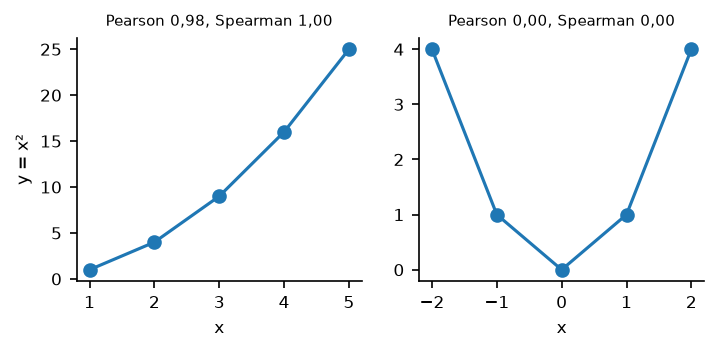

> **Kendall** · *Kendall's tau*
>
> - **Là gì:** cũng dùng thứ hạng: tỷ lệ cặp điểm "cùng chiều" trừ tỷ lệ cặp "ngược chiều".
> - **Ví dụ:** mọi cặp cùng chiều (x lớn hơn thì y lớn hơn) → Kendall = 1.
> - **Để làm gì:** như Spearman, nhưng ổn định hơn khi mẫu nhỏ.

**Lý do.** Pearson đo quan hệ **đường thẳng**, Spearman đo quan hệ **cùng tăng** theo thứ hạng; cả hai bỏ sót chữ U. $y = x^2$ trên
$x$ = −2 … 2: tích độ lệch là −4 + 1 + 0 − 1 + 4 = 0, nên Pearson = 0 dù $y$ hoàn toàn xác định bởi $x$.

**Kết quả.** Bộ tứ Anscombe:

x = [1 2 3 4 5], y = x²: Pearson 0.981, Spearman 1.000
x = [-2 -1  0  1  2], y = x²: Pearson -0.000, Spearman 0.000


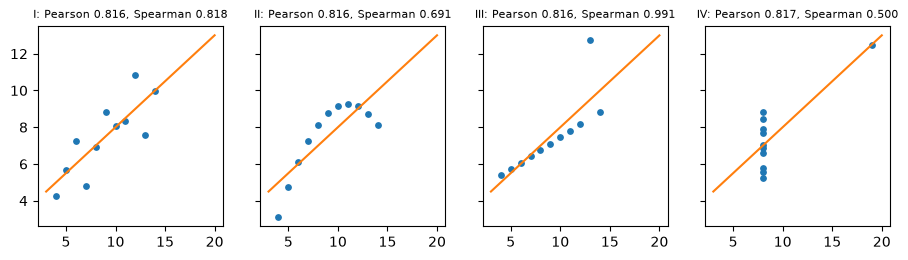

In [3]:
for x in (np.arange(1, 6), np.arange(-2, 3)):
    print(f"x = {x}, y = x²: Pearson {stats.pearsonr(x, x**2)[0] + 0:.3f}, Spearman {stats.spearmanr(x, x**2)[0] + 0:.3f}")

X0 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
ANSCOMBE = {"I": (X0, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
            "II": (X0, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
            "III": (X0, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
            "IV": ([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])}
fig, truc = plt.subplots(1, 4, figsize=(11, 2.6), sharex=True, sharey=True)
for ax, (ten, (x, y)) in zip(truc, ANSCOMBE.items(), strict=True):
    ax.scatter(x, y, s=15)
    ax.plot([3, 20], np.polyval(np.polyfit(x, y, 1), [3, 20]), color="tab:orange")
    ax.set_title(f"{ten}: Pearson {stats.pearsonr(x, y)[0]:.3f}, Spearman {stats.spearmanr(x, y)[0]:.3f}", fontsize=8)
plt.show()

Bốn bộ cùng Pearson 0,82 và cùng đường hồi quy, nhưng là bốn câu chuyện: thẳng có nhiễu, đường cong, thẳng chặt với một điểm lạ, một
cột điểm cộng một điểm kéo cả đường. Spearman khác nhau (0,5 tới 0,99), nhưng chỉ hình mới cho biết chuyện gì xảy ra.

**Bài học.** Vẽ scatter trước khi tin một hệ số tương quan.

## 2. Hai chuỗi cùng đi lên luôn "tương quan cao"

**Vấn đề.** CPI (giá cả) và dân số Mỹ 1990–2024 có $r$ = 0,974. Giá cả và số dân liên quan mạnh tới vậy?

> **hồi quy đơn, R²** · *simple linear regression, coefficient of determination*
>
> - **Là gì:** đường thẳng $y = a + bx$ khớp dữ liệu nhất (tổng bình phương sai lệch nhỏ nhất); $R^2$ là phần dao động của $y$ mà đường thẳng giải thích được.
> - **Ví dụ:** $R^2$ = 0,8: đường thẳng giải thích 80% dao động của $y$.
> - **Để làm gì:** đo "$x$ giải thích $y$ tới đâu" — nhưng chỉ đáng tin khi phần dư không có cấu trúc thời gian.

> **t của hệ số** · *t-statistic*
>
> - **Là gì:** hệ số $b$ chia cho sai số chuẩn của nó (độ lệch chuẩn của chính ước lượng $b$); $|t|$ trên khoảng 2 thường được đọc là "có ý nghĩa".
> - **Ví dụ:** $b$ = 4, sai số chuẩn 1 → $t$ = 4.
> - **Để làm gì:** phân biệt hệ số thật với hệ số do ngẫu nhiên — với giả định sai số độc lập.

> **tương quan giả** · *spurious correlation*
>
> - **Là gì:** $r$ cao chỉ vì hai chuỗi cùng có xu hướng, không vì liên quan.
> - **Ví dụ:** giá cả và dân số cùng tăng theo thời gian → $r$ trên mức rất cao.
> - **Để làm gì:** tránh đưa vào mô hình một biến chỉ "giống" $y$ vì cùng đi lên.

> **Durbin–Watson** · *Durbin–Watson statistic*
>
> - **Là gì:** con số đo phần dư của hồi quy có tự tương quan không: $DW = \sum (e_t - e_{t-1})^2 / \sum e_t^2$; gần 2 là không, gần 0 là tự tương quan dương mạnh.
> - **Ví dụ:** phần dư 1, 1, 1, −1, −1, −1: một bước nhảy cỡ 2 → DW = 4 / 6 ≈ 0,67.
> - **Để làm gì:** phát hiện hồi quy giả: $R^2$ cao đi cùng DW thấp.
>
> 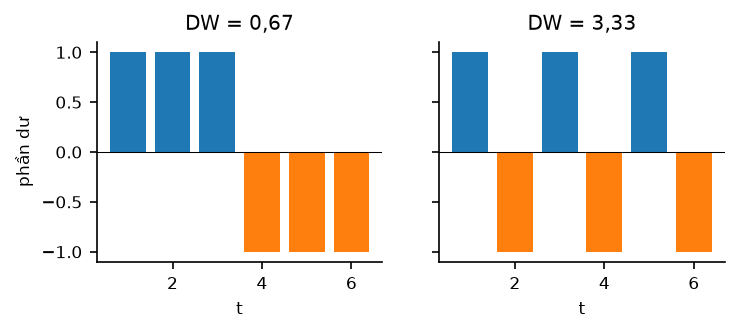

**Lý do.** Hai chuỗi cùng đi lên thì tháng nào cũng "cả hai cao hơn tháng trước"; Pearson thấy điều đó. Câu hỏi đúng: tháng giá tăng
nhanh hơn thường lệ, dân số có tăng nhanh hơn thường lệ không? Sai phân trả lời câu đó. Và phần dư của hồi quy mức đổi chậm (DW gần 0)
nghĩa là phép tính $t$ dựa trên giả định sai.

**Kết quả.** Ví dụ tay 5 tháng, rồi dữ liệu thật:

ví dụ tay: r trên mức 0.974 | r của các bước -1
DW ví dụ: 0.67 3.33
CPI × dân số: r mức 0.974 | R² 0.9495 | t 88.6 | DW 0.0051 | r sau sai phân -0.207


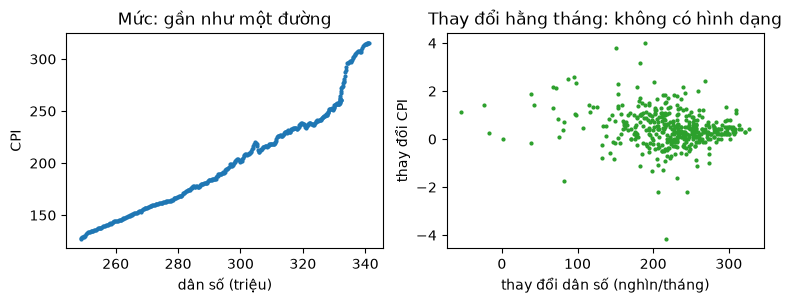

In [4]:
a, b = np.array([2, 3, 5, 6, 8]), np.array([10, 12, 13, 15, 16])
print(f"ví dụ tay: r trên mức {np.corrcoef(a, b)[0, 1]:.3f} | r của các bước {np.corrcoef(np.diff(a), np.diff(b))[0, 1]:.0f}")


def durbin_watson(e):
    return np.sum(np.diff(e) ** 2) / np.sum(e**2)


print("DW ví dụ:", round(durbin_watson(np.array([1, 1, 1, -1, -1, -1])), 2), round(durbin_watson(np.array([1, -1, 1, -1, 1, -1])), 2))


def hoi_quy_don(x, y):
    X = np.column_stack([np.ones(x.size), x])
    he_so = np.linalg.lstsq(X, y, rcond=None)[0]
    du = y - X @ he_so
    se = np.sqrt(du @ du / (x.size - 2) * np.linalg.inv(X.T @ X)[1, 1])
    return 1 - du.var() / y.var(), he_so[1] / se, durbin_watson(du)


r2, t, dw = hoi_quy_don(kt["cpi"].to_numpy(), kt["dan_so"].to_numpy())
d = kt.diff().dropna()
print(f"CPI × dân số: r mức {kt['cpi'].corr(kt['dan_so']):.3f} | R² {r2:.4f} | t {t:.1f} | DW {dw:.4f} | "
      f"r sau sai phân {d['cpi'].corr(d['dan_so']):.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 2.8))
a1.scatter(kt["dan_so"] / 1000, kt["cpi"], s=4)
a1.set(xlabel="dân số (triệu)", ylabel="CPI", title="Mức: gần như một đường")
a2.scatter(d["dan_so"], d["cpi"], s=4, color="tab:green")
a2.set(xlabel="thay đổi dân số (nghìn/tháng)", ylabel="thay đổi CPI", title="Thay đổi hằng tháng: không có hình dạng")
plt.show()

Ba con số đầu nói "quan hệ rất mạnh" ($r$ 0,974, $R^2$ 0,95, $t$ 88,6); hai con số sau nói "mô hình sai" (DW 0,0051, $r$ sau sai
phân −0,207). Ví dụ tay còn rõ hơn: trên mức $r$ = 0,974 nhưng các bước ngược nhau hoàn toàn ($r$ = −1).

**Bài học.** $R^2$ cao, $t$ lớn đi cùng DW gần 0 là dấu hiệu tương quan giả (Granger và Newbold, 1974). Câu hỏi thật được trả lời bằng
tương quan của các **thay đổi**.

## 3. Nhiệt độ và tải: một nhánh âm trộn với một nhánh dương

**Vấn đề.** Pearson nhiệt độ – tải ERCOT là 0,616, "khá mạnh". Nhưng trời lạnh bật sưởi, trời nóng bật điều hoà: cả hai đều làm tải
**tăng**.

> **CDD, HDD** · *cooling / heating degree days*
>
> - **Là gì:** độ nóng / độ lạnh so với mốc 18,33 °C (65 °F): CDD = $\max(T - 18{,}33;\ 0)$, HDD = $\max(18{,}33 - T;\ 0)$.
> - **Ví dụ:** 25 °C → CDD 6,67, HDD 0; 10 °C → CDD 0, HDD 8,33.
> - **Để làm gì:** biến quan hệ chữ V (lạnh bật sưởi, nóng bật điều hoà) thành hai biến, mỗi biến một nhánh, để hồi quy thẳng được.
>
> 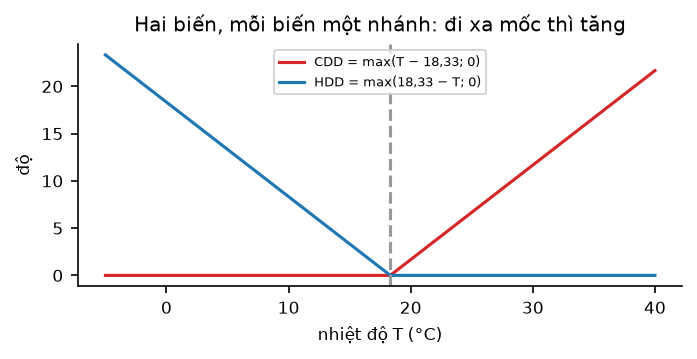

> **mutual information** · *mutual information (MI)*
>
> - **Là gì:** thông tin tương hỗ — biết $x$ thì bớt được bao nhiêu điều chưa biết về $y$: $I = \sum p(x,y) \ln \frac{p(x,y)}{p(x)p(y)}$. Bằng 0 khi độc lập, bắt được mọi dạng quan hệ; đơn vị nat.
> - **Ví dụ:** ngày lạnh → tải cao, vừa → thấp, nóng → cao (mỗi loại 1/3): Pearson 0 nhưng MI ≈ 0,637 nat.
> - **Để làm gì:** phát hiện quan hệ mà Pearson bỏ sót — chữ U, bậc thang.

> **hoán vị theo khối** · *block permutation*
>
> - **Là gì:** xáo trộn cả khối liền nhau thay vì từng điểm, để dữ liệu xáo vẫn giữ độ trơn (tự tương quan) như dữ liệu thật.
> - **Ví dụ:** xáo từng khối 168 giờ (1 tuần) của chuỗi tải: thứ tự các tuần đổi, nhưng trong tuần vẫn là nhịp thật.
> - **Để làm gì:** kiểm một chỉ số (như MI) có ý nghĩa không mà không bị dương tính giả do hai chuỗi cùng trơn.
>
> 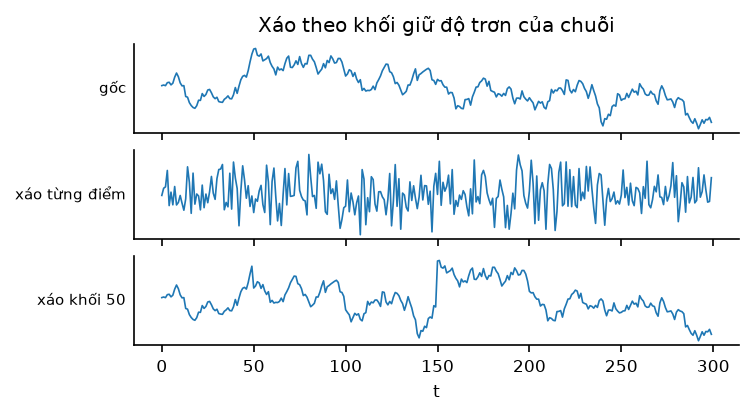

**Lý do.** Quan hệ hình chữ U lệch đổi dấu qua một mốc nhiệt. Tách theo cơ chế: hồi quy tải = $a + b \cdot$CDD $+ c \cdot$HDD vẽ được
chữ V. Hoặc đo bằng MI. Để biết MI có lớn không, so với MI của dữ liệu đã xáo — xáo **theo khối**.

**Kết quả.**

Pearson 0.616 | Spearman 0.733 | Kendall 0.572
R² theo nhiệt độ 0.379 | R² theo CDD + HDD 0.812
≤ 18,33 °C (2,877 giờ): r = -0.649 | > 18,33 °C (5,900 giờ): r = +0.910
mốc cho R² cao nhất: 19.5 °C


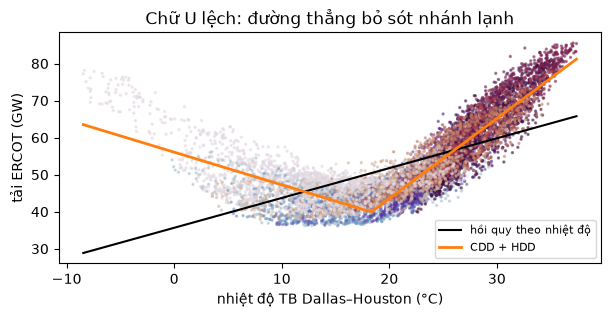

In [5]:
t, y = df["nhiet"].to_numpy(), df["tai"].to_numpy() / 1000
print(f"Pearson {stats.pearsonr(t, y)[0]:.3f} | Spearman {stats.spearmanr(t, y)[0]:.3f} | Kendall {stats.kendalltau(t, y)[0]:.3f}")


def r2_hoi_quy(*cot):
    X = np.column_stack([np.ones(y.size), *cot])
    return 1 - (y - X @ np.linalg.lstsq(X, y, rcond=None)[0]).var() / y.var()


print(f"R² theo nhiệt độ {r2_hoi_quy(t):.3f} | R² theo CDD + HDD {r2_hoi_quy(df['cdd'], df['hdd']):.3f}")
lanh = t <= MOC
print(f"≤ 18,33 °C ({lanh.sum():,} giờ): r = {np.corrcoef(t[lanh], y[lanh])[0, 1]:+.3f} | "
      f"> 18,33 °C ({(~lanh).sum():,} giờ): r = {np.corrcoef(t[~lanh], y[~lanh])[0, 1]:+.3f}")
moc = np.arange(5, 30.1, 0.5)
r2_moc = [r2_hoi_quy(np.maximum(t - m, 0), np.maximum(m - t, 0)) for m in moc]
print(f"mốc cho R² cao nhất: {moc[np.argmax(r2_moc)]:.1f} °C")

fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(t, y, c=df.index.month, cmap="twilight", s=2, alpha=0.5)
g = np.linspace(t.min(), t.max(), 100)
ax.plot(g, np.polyval(np.polyfit(t, y, 1), g), color="k", label="hồi quy theo nhiệt độ")
X = np.column_stack([np.ones(t.size), df["cdd"], df["hdd"]])
h = np.linalg.lstsq(X, y, rcond=None)[0]
ax.plot(g, h[0] + h[1] * np.maximum(g - MOC, 0) + h[2] * np.maximum(MOC - g, 0), color="tab:orange", lw=2, label="CDD + HDD")
ax.set(xlabel="nhiệt độ TB Dallas–Houston (°C)", ylabel="tải ERCOT (GW)", title="Chữ U lệch: đường thẳng bỏ sót nhánh lạnh")
ax.legend(fontsize=8)
plt.show()

Tách hai nhánh, $R^2$ tăng gấp đôi (0,379 → 0,812). Quan hệ **đổi dấu** qua mốc: −0,649 phía lạnh, +0,910 phía nóng; con số
0,616 là trộn của hai nhánh, còn dương chỉ vì ở Texas nhánh nóng dài hơn. Mốc 65 °F là quy ước, gần mốc tốt nhất. Giờ MI, và cách kiểm
nó có ý nghĩa không:

In [6]:
p_xy = np.array([1, 1, 1]) / 3                      # (lạnh, cao), (vừa, thấp), (nóng, cao)
p_x_p_y = np.array([1 / 3 * 2 / 3, 1 / 3 * 1 / 3, 1 / 3 * 2 / 3])
print(f"MI ví dụ tay: {np.sum(p_xy * np.log(p_xy / p_x_p_y)):.3f} nat")


def mi(x, y):
    return mutual_info_regression(np.asarray(x, float).reshape(-1, 1), np.asarray(y, float), random_state=0)[0]


def mi_rong(x, y, do_dai_khoi, so_lan, seed=0):
    # MI của y đã xáo theo khối — phân phối "không có quan hệ"
    rng = np.random.default_rng(seed)
    khoi = [y[i:i + do_dai_khoi] for i in range(0, y.size, do_dai_khoi)]
    return np.array([mi(x, np.concatenate([khoi[i] for i in rng.permutation(len(khoi))])[:x.size]) for _ in range(so_lan)])


# hai chuỗi AR(0,99) ĐỘC LẬP, 2.000 điểm (seed 0)
rng = np.random.default_rng(0)
ar = []
for _ in range(2):
    v = np.empty(2000)
    v[0] = rng.normal()
    for i in range(1, 2000):
        v[i] = 0.99 * v[i - 1] + rng.normal()
    ar.append(v)
mi_that = mi(*ar)
for do_dai in (1, 200):
    rong = mi_rong(ar[0], ar[1], do_dai, 200)
    print(f"hai chuỗi độc lập, xáo khối {do_dai:>3}: MI {mi_that:.3f}, p = {(np.sum(rong >= mi_that) + 1) / 201:.3f}")

mi_ercot = mi(t, y)
rong = mi_rong(t, y, 168, 100)
print(f"nhiệt độ × tải ERCOT: MI {mi_ercot:.3f} nat | ngưỡng 95% khi xáo khối 1 tuần {np.quantile(rong, 0.95):.3f}")

MI ví dụ tay: 0.637 nat
hai chuỗi độc lập, xáo khối   1: MI 0.332, p = 0.005
hai chuỗi độc lập, xáo khối 200: MI 0.332, p = 0.055
nhiệt độ × tải ERCOT: MI 0.862 nat | ngưỡng 95% khi xáo khối 1 tuần 0.124


Với hai chuỗi **không liên quan**, xáo từng điểm cho p = 0,005 — kết luận sai "có quan hệ"; xáo theo khối cho p = 0,055, không bác
bỏ. Với nhiệt độ × tải, MI thật (0,862) vượt xa ngưỡng xáo khối một tuần (0,124): quan hệ có thật.

**Bài học.** Quan hệ đổi dấu làm Pearson sai; tách theo cơ chế (CDD/HDD) hoặc đo bằng MI. Kiểm ý nghĩa trên chuỗi thời gian bằng hoán vị
theo khối.

## 4. Tương quan chéo thô nhoè vì $x$ trơn; prewhiten rồi mới đọc độ trễ

**Vấn đề.** Nóng lên thì bao lâu sau tải mới tăng?

> **tương quan chéo** · *cross-correlation function (CCF)*
>
> - **Là gì:** tương quan giữa $x$ lúc $t$ và $y$ lúc $t + k$, theo độ trễ $k$: $r_k = \operatorname{corr}(x_t, y_{t+k})$; $k$ dương là $x$ đi trước $y$.
> - **Ví dụ:** $y$ chậm 2 bước sau $x$ → đỉnh ở $k$ = 2.
> - **Để làm gì:** tìm độ trễ mà biến giải thích báo trước $y$ — quyết định dùng giá trị $x$ của lúc nào.

> **prewhitening**
>
> - **Là gì:** lọc bỏ phần $x$ "tự đoán được từ quá khứ của nó" (khớp AR cho $x$), lọc $y$ bằng **đúng** bộ lọc đó, rồi mới tính tương quan chéo.
> - **Ví dụ:** $x$ là random walk thì lọc = lấy sai phân; tương quan chéo trên hai dãy bước còn đúng một đỉnh sắc.
> - **Để làm gì:** tương quan chéo thô mang hình dạng tự tương quan của chính $x$; lọc xong mới đọc được độ trễ thật.

**Lý do.** Nếu $x$ rất trơn ($x_t$ giống $x_{t+1}$), khi $y$ đi theo $x$ chậm 2 bước thì tương quan chéo cao ở **cả dải** trễ quanh 2.
Prewhitening bỏ độ trơn đó. Và kiểm hướng của thư viện: `statsmodels.tsa.stattools.ccf(a, b)` trả $\operatorname{corr}(a_{t+k}, b_t)$ —
muốn "$x$ dẫn $y$" phải gọi `ccf(y, x)`.

**Kết quả.**

ví dụ tay, thô      : [0.15 0.42 0.77 0.37 0.05]
ví dụ tay, sau lọc  : [-0.09 -0.1   0.91 -0.01 -0.11]
kiểm hướng: ccf_tu_viet(x, y) đỉnh ở 3 | statsmodels ccf(y, x) đỉnh ở 3


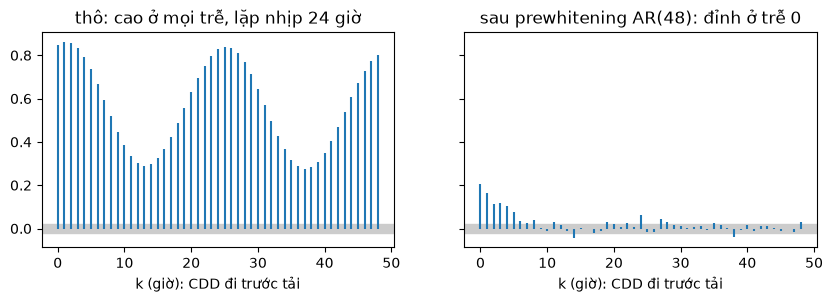

thô      trễ 0, 1, 24: [0.848 0.863 0.828]
sau lọc  trễ 0, 1, 24: [0.205 0.163 0.061]


In [7]:
def ccf_tu_viet(x, y, so_tre):
    x, y = np.asarray(x, float), np.asarray(y, float)
    x, y = (x - x.mean()) / x.std(), (y - y.mean()) / y.std()
    return np.array([np.sum(x[:x.size - k] * y[k:]) / x.size for k in range(so_tre + 1)])      # corr(x_t, y_{t+k})


x = np.array([1, 2, 1, 2, 3, 4, 3, 2, 1, 2, 1, 0])
y_tay = np.r_[1, 1, x[:-2]]                                   # y_t = x_{t−2}
print("ví dụ tay, thô      :", ccf_tu_viet(x, y_tay, 4).round(2))
print("ví dụ tay, sau lọc  :", ccf_tu_viet(np.diff(x), np.diff(y_tay), 4).round(2))
gia = np.random.default_rng(1).normal(size=200)
tre3 = np.r_[np.zeros(3), gia[:-3]]                           # tre3_t = gia_{t−3}
print("kiểm hướng: ccf_tu_viet(x, y) đỉnh ở", ccf_tu_viet(gia, tre3, 6).argmax(),
      "| statsmodels ccf(y, x) đỉnh ở", ccf(tre3, gia, nlags=7).argmax())


def loc_prewhiten(x, y, bac=48):
    phi = AutoReg(x, lags=bac).fit().params[1:]              # hệ số AR(48) của x
    loc = lambda v: np.array([v[i] - phi[::-1] @ v[i - bac:i] for i in range(bac, v.size)])   # noqa: E731
    return loc(x), loc(y)                                    # lọc CẢ HAI bằng cùng phi


cdd, taiv = df["cdd"].to_numpy(), df["tai"].to_numpy()
tho = ccf_tu_viet(cdd, taiv, 48)
sach = ccf_tu_viet(*loc_prewhiten(cdd, taiv), 48)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True)
for ax, r, ten in ((a1, tho, "thô: cao ở mọi trễ, lặp nhịp 24 giờ"), (a2, sach, "sau prewhitening AR(48): đỉnh ở trễ 0")):
    ax.vlines(range(49), 0, r)
    ax.axhspan(-2 / np.sqrt(len(cdd)), 2 / np.sqrt(len(cdd)), color="0.8")
    ax.set(title=ten, xlabel="k (giờ): CDD đi trước tải")
plt.show()
print("thô      trễ 0, 1, 24:", tho[[0, 1, 24]].round(3))
print("sau lọc  trễ 0, 1, 24:", sach[[0, 1, 24]].round(3))

Ví dụ tay: thô thì đỉnh ở 2 nhưng trễ 1 và 3 cũng khá cao; sau lọc chỉ còn một đỉnh sắc ở 2. Trên ERCOT, thô thì trễ 24 (0,828)
cao gần bằng trễ 0 — đó là nhịp ngày của chính CDD; sau lọc chỉ còn đỉnh ở trễ 0 (0,205), tắt dần sau vài giờ: tải phản ứng với nóng
gần như ngay trong giờ.

**Bài học.** Prewhiten trước khi đọc độ trễ; kiểm quy ước hướng của thư viện bằng chuỗi giả $y_t = x_{t-3}$.

## 5. Tương quan trượt: âm cuối mùa đông, gần +1 mùa hè

**Vấn đề.** Phần 3 cho thấy quan hệ đổi dấu qua mốc nhiệt. Theo **thời gian** trong năm thì sao?

> **tương quan trượt** · *rolling correlation*
>
> - **Là gì:** $r$ tính trên từng cửa sổ thời gian (ví dụ 90 ngày), vẽ theo thời gian.
> - **Ví dụ:** ba ngày đông (5, 10, 15 °C; tải 30, 20, 10) có $r$ = −1; ba ngày hè (25, 30, 35 °C; tải 20, 30, 40) có $r$ = +1; gộp sáu ngày $r$ = 0,48.
> - **Để làm gì:** thấy quan hệ có ổn định không, trước khi dùng một hệ số cho cả năm.

**Lý do.** Một hệ số cho cả năm là trung bình của các chế độ ngược nhau. Tính $r$ trên cửa sổ trượt để thấy từng chế độ. Lưu ý:
`rolling("90D")` mặc định chỉ cần 1 điểm nên vài giá trị đầu là ±1 giả — đặt `min_periods` rõ ràng.

**Kết quả.**

ví dụ tay, gộp sáu ngày: r = 0.48


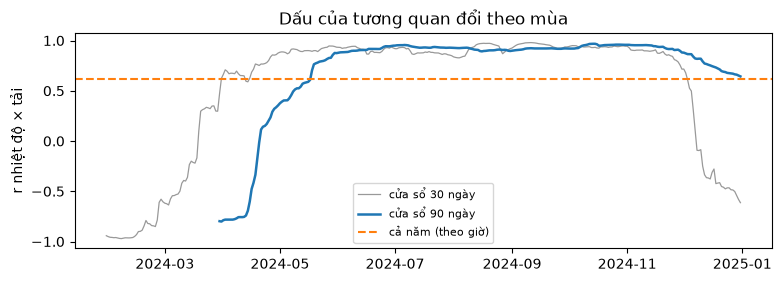

90 ngày: 31/3 -0.801, 14/10 +0.968 | 30 ngày thấp nhất -0.971


In [8]:
ngay = df.resample("D").mean()
print("ví dụ tay, gộp sáu ngày: r =", round(np.corrcoef([5, 10, 15, 25, 30, 35], [30, 20, 10, 20, 30, 40])[0, 1], 2))
r90 = ngay["nhiet"].rolling(90, min_periods=90).corr(ngay["tai"])
r30 = ngay["nhiet"].rolling(30, min_periods=30).corr(ngay["tai"])
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(r30, color="0.6", lw=0.9, label="cửa sổ 30 ngày")
ax.plot(r90, lw=1.8, label="cửa sổ 90 ngày")
ax.axhline(df["nhiet"].corr(df["tai"]), color="tab:orange", ls="--", label="cả năm (theo giờ)")
ax.set(ylabel="r nhiệt độ × tải", title="Dấu của tương quan đổi theo mùa")
ax.legend(fontsize=8)
plt.show()
print(f"90 ngày: 31/3 {r90['2024-03-31']:+.3f}, 14/10 {r90['2024-10-14']:+.3f} | 30 ngày thấp nhất {r30.min():+.3f}")

Cửa sổ 90 ngày kết thúc 31/3 cho −0,801, kết thúc 14/10 cho +0,968; cửa sổ 30 ngày còn xuống tới −0,971. Con số cả năm (0,616) nằm
giữa, không đúng với mùa nào.

**Bài học.** Báo tương quan luôn kèm "trên khoảng thời gian nào" và một hình trượt. Mô hình học chỉ trên mùa hè ("nóng hơn thì tải cao
hơn") sẽ đoán **sai dấu** trong đợt rét.

## 6. Granger có ý nghĩa ở cả hai chiều: dấu hiệu của biến gây nhiễu

**Vấn đề.** Nhiệt độ có "gây ra" tải điện không? Kiểm định mang tên "Granger causality" đo một thứ hẹp hơn nhiều.

> **kiểm định Granger** · *Granger causality test*
>
> - **Là gì:** hỏi: thêm quá khứ của $x$ có làm dự báo $y$ tốt hơn hẳn so với chỉ dùng quá khứ của $y$ không.
> - **Ví dụ:** $y$ luôn bằng $x$ hôm trước: đoán bằng $y$ hôm qua có tổng bình phương sai số 38, đoán bằng $x$ hôm qua ra 0.
> - **Để làm gì:** đo "quá khứ X giúp dự báo Y" — không phải "X gây ra Y".

> **biến gây nhiễu** · *confounder*
>
> - **Là gì:** biến thứ ba điều khiển cả $x$ lẫn $y$, làm chúng trông như liên quan.
> - **Ví dụ:** nhịp ngày điều khiển cả nhiệt độ (mặt trời) lẫn tải (người thức dậy dùng điện).
> - **Để làm gì:** giải thích vì sao tương quan hay Granger có ý nghĩa mà không có nhân quả.
>
> 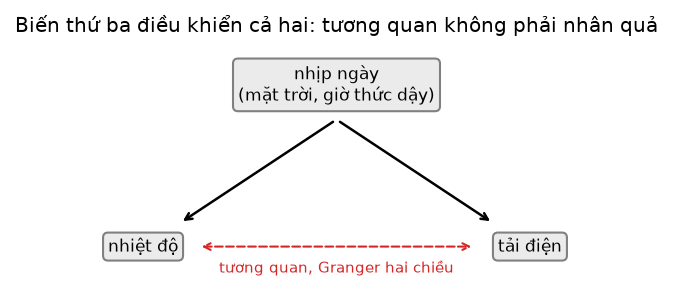

> **ex-ante / ex-post** · *ex-ante / ex-post forecast*
>
> - **Là gì:** ex-ante: dự báo chỉ dùng thông tin đã có lúc ra dự báo. Ex-post: dùng cả giá trị thật về sau của biến giải thích.
> - **Ví dụ:** dùng nhiệt độ **dự báo** ngày mai là ex-ante; dùng nhiệt độ **đo được** ngày mai là ex-post.
> - **Để làm gì:** biến chỉ dùng được cho dự báo thật nếu lúc ra dự báo ta biết (hoặc dự báo được) giá trị tương lai của nó.

**Lý do.** Granger so hai cách dự báo $y$: chỉ dùng quá khứ của $y$, và dùng thêm quá khứ của $x$. Sai số nhỏ đi rõ rệt thì "quá khứ $x$
giúp dự báo $y$". Nếu cả hai chiều đều có ý nghĩa, thường có một biến thứ ba điều khiển cả hai.

**Kết quả.**

tổng bình phương sai số — A (y hôm qua): 38.0 | B (x hôm qua): 0.0
CDD → tải: p = 1.43e-221 | tải → CDD: p = 5.56e-141


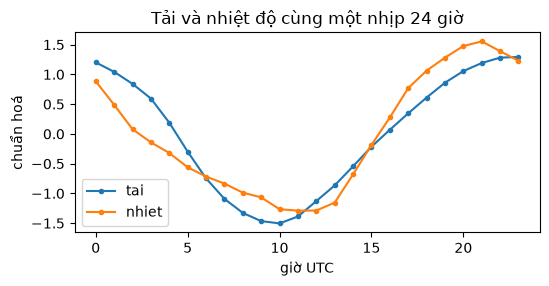

In [9]:
xg = np.array([3, 1, 4, 1, 5, 9])
yg = np.r_[np.nan, xg[:-1]]                                   # y hôm nay = x hôm qua
print("tổng bình phương sai số — A (y hôm qua):", np.nansum((yg[2:] - yg[1:-1]) ** 2), "| B (x hôm qua):", np.sum((yg[2:] - xg[1:-1]) ** 2))


def granger_p(nguyen_nhan, ket_qua, so_tre=4):
    # statsmodels kiểm: CỘT 2 có giúp dự báo CỘT 1 không; lấy p nhỏ nhất qua các độ trễ 1..so_tre
    kq = grangercausalitytests(np.column_stack([ket_qua, nguyen_nhan]), maxlag=so_tre)
    return min(kq[k][0]["ssr_ftest"][1] for k in kq)


print(f"CDD → tải: p = {granger_p(cdd, taiv):.2e} | tải → CDD: p = {granger_p(taiv, cdd):.2e}")

gio = df.index.hour
ho = df[["tai", "nhiet"]].groupby(gio).mean()
ho = (ho - ho.mean()) / ho.std()
ax = ho.plot(figsize=(6, 2.6), marker="o", ms=3, title="Tải và nhiệt độ cùng một nhịp 24 giờ")
ax.set(xlabel="giờ UTC", ylabel="chuẩn hoá")
plt.show()

Cả hai chiều p gần 0 — kể cả khi hỏi "tải có giúp dự báo nhiệt độ không". "Tải điện gây ra nhiệt độ ngoài trời" là vô lý: cả hai cùng
chạy theo nhịp ngày. Hai điều kiện nữa: chuỗi phải **dừng** (sai phân trước), và kết luận luôn viết "quá khứ X giúp dự báo Y".

Nhiệt độ dùng được cho dự báo tải vì có dự báo thời tiết — nhưng phải dùng nhiệt độ **dự báo** (ex-ante), kèm sai số của nó. Dùng
nhiệt độ đo được ngày mai là ex-post: hữu ích để nghiên cứu mô hình, không phải dự báo thật.

**Bài học.** Chạy Granger cả hai chiều; và với mọi biến giải thích, hỏi: lúc ra dự báo có biết giá trị tương lai của nó không?

## 7. Bài tập về nhà — đáp số

**Bài 1 — Mô phỏng tương quan giả.** 1.000 cặp random walk **độc lập**, 200 điểm mỗi chuỗi (seed 0):

In [10]:
rng = np.random.default_rng(0)
r_muc, r_sp = [], []
for _ in range(1000):
    u, v = rng.normal(size=(2, 200)).cumsum(axis=1)
    r_muc.append(np.corrcoef(u, v)[0, 1])
    r_sp.append(np.corrcoef(np.diff(u), np.diff(v))[0, 1])
print(f"|r| > 0,5: trên mức {np.mean(np.abs(r_muc) > 0.5):.1%} | sau sai phân {np.mean(np.abs(r_sp) > 0.5):.1%}")

|r| > 0,5: trên mức 37.9% | sau sai phân 0.0%


Hai random walk không liên quan gì mà 37,9% số cặp có $|r| > 0{,}5$ trên mức; sau sai phân không cặp nào. Tương quan
giả không phải chuyện hiếm — nó là điều **mặc định** khi hai chuỗi không dừng.

**Bài 2 — Vùng khác (ISNE).** Cần tự tải nhiệt độ Boston theo giờ UTC từ Open-Meteo. Cách làm: ghép với tải `ISNE` theo mốc UTC, lặp
phần 3 (Pearson, CDD/HDD, tách nhánh) và phần 5 (tương quan trượt 90 ngày). Điều cần xem: New England lạnh hơn nên nhánh **lạnh** dài
hơn nhánh nóng — dấu của Pearson cả năm phụ thuộc nhánh nào dài hơn, đúng như lý giải cho Texas.

**Bài 3 — Lọc ngược:** prewhiten bằng AR của **tải** thay vì của CDD.

In [11]:
nguoc = ccf_tu_viet(*loc_prewhiten(taiv, cdd)[::-1], 48)    # khớp AR cho tải, lọc cả hai, rồi CCF "CDD đi trước tải"
print("lọc theo CDD  trễ 0, 1, 2, 24:", sach[[0, 1, 2, 24]].round(3))
print("lọc theo tải  trễ 0, 1, 2, 24:", nguoc[[0, 1, 2, 24]].round(3))

lọc theo CDD  trễ 0, 1, 2, 24: [0.205 0.163 0.113 0.061]
lọc theo tải  trễ 0, 1, 2, 24: [0.11  0.103 0.063 0.008]


Hai cách lọc cho hai dãy khác nhau: bộ lọc làm "trắng" chuỗi nào thì chỉ chuỗi đó thành nhiễu trắng, chuỗi kia vẫn còn độ trơn riêng
và làm nhoè tương quan chéo theo kiểu của nó. Box–Jenkins lọc theo chuỗi **giải thích** vì câu hỏi là "$x$ báo trước $y$ bao lâu": làm $x$
trắng thì mỗi cú sốc của $x$ là một xung đơn, và tương quan chéo đọc thẳng ra phản ứng của $y$ theo từng độ trễ.

## Tự kiểm

- [ ] Tính Spearman cho $x$ = 1, 2, 3, 4 và $y$ = 10, 20, 30, 1.000.
- [ ] Nói được ba dấu hiệu tương quan giả ($r$ sụp sau sai phân, DW gần 0, $R^2$ cao).
- [ ] Tính CDD, HDD cho 10 °C và 25 °C.
- [ ] Giải thích vì sao phải hoán vị theo khối khi kiểm MI.
- [ ] Đọc đúng hướng của `statsmodels.tsa.stattools.ccf(x, y)`.
- [ ] Giải thích vì sao Granger hai chiều cùng có ý nghĩa không phải nhân quả.